# Boundary QA

This notebook does a quick quality-assurance pass over the library-owned NYC boundary layers bundled with `nyc311`.

It checks:
- expected geography keys
- geometry types
- join coverage against the packaged point-capable sample service-request records
- an in-memory boundary and point preview

In [1]:
import nyc311
from IPython.display import display

sample_boundaries = nyc311.load_sample_boundaries("community_district")
boundaries_gdf = nyc311.load_boundaries_geodataframe(sample_boundaries)
records = nyc311.load_sample_service_requests()
points_gdf = nyc311.records_to_geodataframe(records)
joined = nyc311.spatially_enrich_records(
    records,
    boundaries=sample_boundaries,
)

In [2]:
boundary_summary = boundaries_gdf.assign(
    geometry_type=boundaries_gdf.geometry.geom_type,
)[["geography", "geography_value", "geometry_type"]]

join_coverage = joined["boundary_geography_value"].notna().mean()
print(f"Join coverage: {join_coverage:.1%}")
display(boundary_summary)

Join coverage: 66.7%


,geography,geography_value,geometry_type
0,community_district,MANHATTAN 10,MultiPolygon
1,community_district,BRONX 05,MultiPolygon
2,community_district,BROOKLYN 01,MultiPolygon
3,community_district,BROOKLYN 03,MultiPolygon
4,community_district,QUEENS 02,MultiPolygon


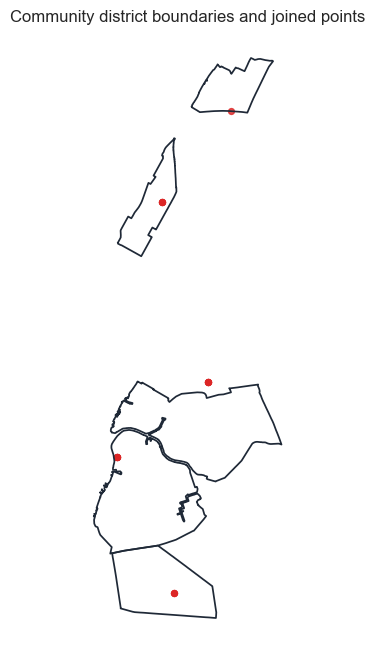

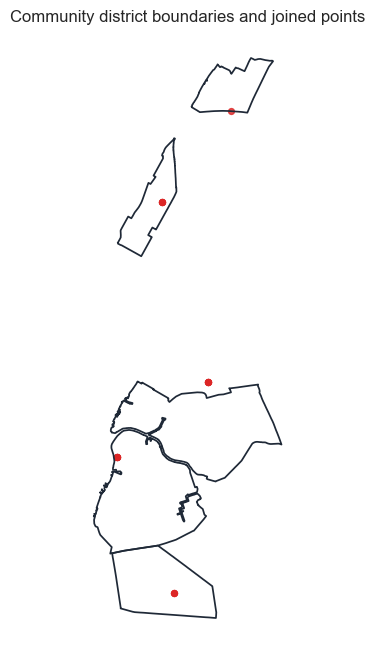

In [3]:
figure = nyc311.plot_boundary_preview(
    boundaries_gdf,
    points_gdf=points_gdf,
    title="Community district boundaries and joined points",
)
figure